#  프로젝트: Transformer 한영 번역기 만들기

> **목표**: "Attention is All You Need" 논문의 Transformer 아키텍처를 처음부터 직접 구현하여 한국어 → 영어 번역기를 만든다.
>
> **데이터**: korean-parallel-corpora (한국어-영어 뉴스 병렬 코퍼스, 약 9만 쌍)

---

##  프로젝트 평가 기준 (루브릭)

| 학습 목표 | 평가 기준 |
|---|---|
| 텍스트 데이터 전처리 | 데이터 정제, SentencePiece 토큰화 |
| Transformer 정상 구동 | 학습과 추론 정상 동작 |
| 의미 있는 번역 결과 | 그럴듯한 영어 번역 + Attention Map |

---

##  노트북 구성

1. 환경 설정
2. 데이터 준비
3. 토크나이저 (SentencePiece)
4. 텐서화
5. 모델 구현
6. 마스크 생성
7. 하이퍼파라미터 & 인스턴스화
8. Optimizer / Scheduler / Loss
9. 학습 루프
10. 번역 (Greedy Decoding)
11. Attention 시각화
12. 프로젝트 회고

---

##  이전 시도에서 폭망한부분..

처음에 학습이 발산했던 (loss=6495) 원인 3가지:
- **Gradient Clipping 부재** → 폭발 방지 필요
- **Label Smoothing 부재** → 안정적 학습 신호 필요  
- **Xavier 초기화 부재** → 좋은 출발점 필요



---

# 1 환경 설정



In [1]:
import os
import re
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# 진행률 표시
from tqdm.notebook import tqdm

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu118
Device:  cuda
GPU:     Tesla T4


---

# 2️ 데이터 다운로드 & 정제

## 2.1 데이터 다운로드

In [2]:
# 데이터 저장 디렉토리 생성
!mkdir -p ~/work/transformer/data

# 데이터 다운로드 (이미 받았으면 스킵)
data_dir = os.path.join(os.getenv("HOME"), "work/transformer/data")
kor_path = os.path.join(data_dir, "korean-english-park.train.ko")
eng_path = os.path.join(data_dir, "korean-english-park.train.en")

if not (os.path.exists(kor_path) and os.path.exists(eng_path)):
    !wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz \
        -O ~/work/transformer/data/korean-english-park.train.tar.gz
    !tar -xzf ~/work/transformer/data/korean-english-park.train.tar.gz -C ~/work/transformer/data/

print(f"한국어: {kor_path} ({'존재' if os.path.exists(kor_path) else '없음'})")
print(f"영어:   {eng_path} ({'존재' if os.path.exists(eng_path) else '없음'})")

한국어: /home/jovyan/work/transformer/data/korean-english-park.train.ko (존재)
영어:   /home/jovyan/work/transformer/data/korean-english-park.train.en (존재)


## 2.2 정제 & 전처리

- **중복 제거**: 같은 한영 쌍이 여러 번 등장하면 학습 다양성 ↓
- **전처리**: 소문자화, 특수문자 제거, 구두점 분리

>  구두점을 단어로부터 분리하는 게 중요. 토크나이저가 "안녕,"을 한 단어로 보지 않고 "안녕"과 ","로 따로 인식하도록.

In [3]:
def preprocess_sentence(sentence: str) -> str:
    """문장 단위 전처리."""
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)              # 구두점 분리
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)        # 한/영/구두점 외 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()                # 연속 공백 정리
    return sentence


def load_pairs(kor_path, eng_path):
    """한영 병렬 코퍼스를 읽어 중복 제거."""
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng)
    
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs


pairs = load_pairs(kor_path, eng_path)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print(f"\n샘플:")
for i in range(3):
    print(f"  [한] {pairs[i][0]}")
    print(f"  [영] {pairs[i][1]}\n")

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]

중복 제거 후 병렬쌍: 78,968

샘플:
  [한] 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  [영] much of personal computing is about can you top this ?

  [한] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  [영] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .

  [한] 그러나 이것은 또한 책상도 필요로 하지 않는다 .
  [영] like all optical mice , but it also doesn t need a desk .



---

# 3️⃣ SentencePiece 토크나이저

## 왜 vocab=8000인가? 🤔

원래 우리는 20,000을 썼는데, 정답 코드는 **8,000**을 권장.

이유: **데이터 크기 ↔ vocab 크기는 균형**이 중요 카사딘이 말했다 힘의균형은 중요하다고.

```
데이터 9만 쌍 → vocab 20K: 자주 등장 안 하는 토큰이 많아짐 → 학습 어려움
데이터 9만 쌍 → vocab 8K:  토큰 빈도 ↑ → 학습 효율 ↑
```

## 특수 토큰

| ID | 토큰 | 역할 |
|---|---|---|
| 0 | `<pad>` | 패딩 |
| 1 | `<bos>` | 디코더 시작 신호 |
| 2 | `<eos>` | 생성 종료 신호 |
| 3 | `<unk>` | 모르는 토큰 |

In [4]:
import sentencepiece as spm

# vocab 크기 — 8K로 설정 (작은 데이터에 적합)
SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

# 특수 토큰 ID (전역 상수로)
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3


def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """SentencePiece BPE 토크나이저 학습."""
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    
    # 코퍼스를 임시 파일로 저장
    with open(txt_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")
    
    # 옵션 사이 공백 잘 챙기기! (이전에 우리가 빠뜨렸던 버그)
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk


print("토크나이저 학습 중... (1~2분 소요)")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 영어는 항상 <bos>...<eos>로 감싸도록 (디코더 입력 형태)
en_tokenizer.set_encode_extra_options("bos:eos")

print(f"\n한국어 vocab: {ko_tokenizer.get_piece_size():,}")
print(f"영어 vocab:   {en_tokenizer.get_piece_size():,}")
print(f"\n샘플 인코딩:")
print(f"  한: {ko_tokenizer.encode_as_pieces('딥러닝은 흥미롭다')}")
print(f"  영: {en_tokenizer.encode_as_pieces('deep learning is interesting')}")

토크나이저 학습 중... (1~2분 소요)


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca


한국어 vocab: 8,000
영어 vocab:   8,000

샘플 인코딩:
  한: ['▁', '딥', '러', '닝', '은', '▁흥미', '롭', '다']
  영: ['<s>', '▁deep', '▁learning', '▁is', '▁interest', 'ing', '</s>']


 Final character coverage=0.999909
trainer_interface.cc(594) LOG(INFO) Done! preprocessed 78956 sentences.
trainer_interface.cc(600) LOG(INFO) Tokenizing input sentences with whitespace: 78956
trainer_interface.cc(611) LOG(INFO) Done! 44562
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=269076 min_freq=1
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=76902 size=20 all=1388 active=1358 piece=at
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=41118 size=40 all=2518 active=2488 piece=id
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=21998 size=60 all=3739 active=3709 piece=ut
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=16676 size=80 all=5227 active=5197 piece=ver
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=12810 size=100 all=6217 active=6187 piece=▁al
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=12564 min_freq=1020
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=10114 size=120 all=7501 active=2242 piece=her
bpe_model_trainer.cc(268

---

# 4️ 텐서화 (길이 ≤ 40)

너무 긴 문장은 학습이 어렵고 메모리 부담이 크니 **40 토큰 이하만** 사용.

In [5]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in tqdm(list(zip(kor_corpus, eng_corpus)), desc="Tokenizing"):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    
    # 너무 짧은 것도 제외 (영어는 <bos>, <eos> 빼면 1단어 이상)
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"\n학습용 병렬쌍: {len(src_corpus):,}")
print(f"src 평균 길이: {np.mean([len(s) for s in src_corpus]):.1f}")
print(f"tgt 평균 길이: {np.mean([len(t) for t in tgt_corpus]):.1f}")

Tokenizing:   0%|          | 0/78968 [00:00<?, ?it/s]


학습용 병렬쌍: 58,876
src 평균 길이: 22.7
tgt 평균 길이: 25.2


---

# 5️ Transformer 모델 구현

## 핵심 개선 사항

| 개선점 | 효과 |
|---|---|
| **마스크 컨벤션 통일** (`True` = 가려라) | 버그 없는 일관된 처리 |
| **GELU** 활성화 함수 (ReLU 대신) | 더 부드러운 gradient |
| **Xavier 초기화** | 안정적인 학습 시작 |
| **Pre-LN** (Norm을 먼저) | 깊은 모델 학습 안정성 |
| `padding_idx=0` 임베딩 | 패딩 위치 학습 안 함 |
| `register_buffer`로 PE | GPU로 자동 이동 |
| **항상** `sqrt(d_model)` 스케일 | 원논문 충실 |

In [6]:
def positional_encoding(pos_len, d_model):
    """Sinusoidal Positional Encoding. torch.Tensor로 직접 반환."""
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention.
    마스크 컨벤션: True = 가려라 (masked_fill 사용).
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        
        # Q, K, V 가중치 (하나의 큰 Linear로 만들고 reshape로 head 분할)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)  # W^O
        self.attn_dropout = nn.Dropout(dropout)
    
    def _split(self, x):
        """(B, T, D) → (B, H, T, D/H)"""
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)
    
    def _combine(self, x):
        """(B, H, T, D/H) → (B, T, D)"""
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)
    
    def forward(self, Q, K, V, mask=None):
        # 1️⃣ Q, K, V 생성 + head 분할
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))
        
        # 2️⃣ Scaled Dot-Product: QK^T / √d_k
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        
        # 3️⃣ 마스킹: True인 곳을 -inf로 → softmax 후 0
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        
        # 4️⃣ Softmax + Dropout
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        
        # 5️⃣ Value와 가중합 + Head 합치기 + W^O
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    """
    Position-wise FFN.
    GELU 활성화 사용 (ReLU보다 부드럽고 현대적).
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    """Encoder 한 층: Self-Attention + FFN (Pre-LN)."""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, src_mask):
        # ① Self-Attention (Pre-LN)
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)  # Residual
        
        # ② FFN (Pre-LN)
        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))  # Residual
        return x, attn


class DecoderLayer(nn.Module):
    """Decoder 한 층: Masked Self-Attn + Cross-Attn + FFN."""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, enc_out, tgt_mask, memory_mask):
        # ① Masked Self-Attention (미래 + 패딩 차단)
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)
        
        # ② Cross-Attention (Q=디코더, K/V=인코더)
        # 중요: memory_mask는 인코더 패딩만! causal mask 들어가면 안 됨
        h = self.norm_2(x)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)
        
        # ③ FFN
        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
    
    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
    
    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa)
            cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared
        
        # 임베딩 (padding_idx=0: 패딩 위치는 학습 안 함)
        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        
        # Positional Encoding을 buffer로 등록 (GPU 자동 이동, save/load 포함)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)
        
        # 인코더 / 디코더
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        
        # 최종 출력 Linear (bias 없음, weight tying을 위해)
        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight  # Weight Tying
        
        # ⭐ Xavier 초기화 — 학습 안정성의 핵심
        self._reset_parameters()
    
    def _reset_parameters(self):
        """Xavier uniform 초기화로 시작점을 안정화."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def _embed(self, emb, x):
        """임베딩 + √d_model 스케일 + 위치 인코딩 + Dropout."""
        # 원논문: 항상 sqrt(d_model)로 스케일 (shared 여부와 무관)
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)
    
    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)
        
        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("✅ 모델 클래스 정의 완료")

✅ 모델 클래스 정의 완료


---

# 6️ 마스크 (Mask) 생성

**컨벤션: `True` = 가려라** (이 컨벤션으로 통일하면 헷갈릴 일 없음)

| 마스크 | 용도 | 차단 대상 |
|---|---|---|
| `src_mask` | 인코더 self-attn | 인코더 패딩 |
| `tgt_mask` | 디코더 self-attn | 디코더 패딩 + **미래 토큰** |
| `memory_mask` | Cross-attention | 인코더 패딩 (causal 없음!) |



In [7]:
def padding_mask(seq):
    """PAD 위치를 True로. shape: [B, 1, 1, T]"""
    return (seq == 0).unsqueeze(1).unsqueeze(2)


def causal_mask(size, device):
    """미래 위치를 True로. shape: [1, 1, size, size]"""
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)


def generate_masks(src, tgt):
    """학습/추론에 필요한 3가지 마스크를 한 번에 생성."""
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    
    tgt_mask = tgt_pad | tgt_causal                            # 패딩 OR 미래
    memory_mask = src_pad                                      # cross-attn은 enc 패딩만!
    
    return src_pad, tgt_mask, memory_mask


# 마스크 동작 확인
test_causal = causal_mask(6, "cpu").squeeze().int().numpy()
print("Causal Mask (1=가려짐, 0=보임):")
print(test_causal)

Causal Mask (1=가려짐, 0=보임):
[[0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]


---

# 7️ 하이퍼파라미터 & 모델 인스턴스화

## 설정 근거

| 항목 | 값 | 근거 |
|---|---|---|
| `n_layers` | 4 | 작은 데이터엔 적당히 깊게 |
| `d_model` | 256 | 512는 과함 |
| `d_ff` | 1024 | d_model의 4배 (논문 비율) |
| `n_heads` | 8 | 표준 |
| `dropout` | 0.1 | Xavier+LabelSmooth가 정규화 역할도 함 |
| `batch_size` | 128 | 작은 모델이라 OK |
| `epochs` | 20 | 충분히 수렴 |
| `warmup_steps` | 4000 | 논문 권장 |
| `label_smoothing` | 0.1 | 학습 안정화 |

In [8]:
# 모델 하이퍼파라미터
N_LAYERS = 4
D_MODEL = 256
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.1
POS_LEN = MAX_LEN + 2

# 학습 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

# 모델 인스턴스화
model = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")
print(f"디바이스:    {next(model.parameters()).device}")

파라미터 수: 11.47M
디바이스:    cuda:0


---

# 8️ Optimizer / Scheduler / Loss

##  Label Smoothing Loss

일반 CrossEntropy의 문제:
```
정답: "student" → 확률 100%
나머지 단어들    → 확률 0%
→ 모델이 너무 확신에 차서 학습이 들쭉날쭉
```

Label Smoothing 해결책:
```
정답: "student" → 확률 90% (1 - 0.1)
나머지 단어들    → 확률 10%를 분산
→ 부드러운 학습 신호 → 안정적
```

##  Noam Scheduler (LambdaLR로 깔끔하게)

$$lr = d_{model}^{-0.5} \times \min(step^{-0.5}, step \times warmup^{-1.5})$$

✅ Optimizer / Scheduler / Loss 준비 완료


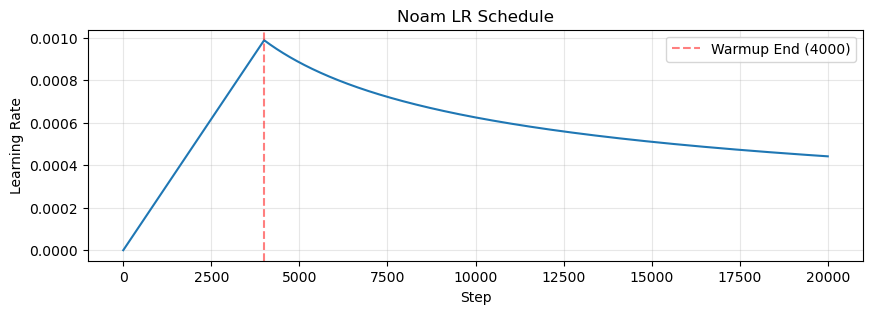

In [9]:
def noam_lr(d_model, warmup):
    """Transformer 논문의 warmup + inverse sqrt decay 스케줄."""
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr


# Optimizer (lr=1.0은 scheduler가 매 step 덮어쓸 거라 임시값)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """
    Label Smoothing + PAD 무시 + KL Divergence 기반.
    Cross Entropy보다 학습이 훨씬 안정적이고 일반화 성능도 좋음.
    """
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing
    
    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        
        with torch.no_grad():
            # 모든 위치에 균등 분포 (smoothing/(V-2): PAD와 정답 제외)
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            # 정답 위치엔 (1 - smoothing) 확률
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            # PAD 차원은 0으로
            true_dist[:, :, self.pad_id] = 0
            # PAD 위치 자체는 loss에서 제외
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)

print("✅ Optimizer / Scheduler / Loss 준비 완료")

# 학습률 곡선 미리보기
lrs = [noam_lr(D_MODEL, WARMUP_STEPS)(s) for s in range(1, 20000)]
plt.figure(figsize=(10, 3))
plt.plot(lrs)
plt.axvline(WARMUP_STEPS, color='r', linestyle='--', alpha=0.5, label=f'Warmup End ({WARMUP_STEPS})')
plt.xlabel('Step'); plt.ylabel('Learning Rate'); plt.title('Noam LR Schedule')
plt.legend(); plt.grid(alpha=0.3); plt.show()

---

# 9️ 학습 루프

##  동적 패딩 (Mini-batch Padding)

전체를 한 번에 패딩하면 모든 시퀀스가 가장 긴 문장 길이로 늘어나서 메모리/속도 비효율적.
**배치 단위로만 패딩**하면 짧은 배치는 짧게, 긴 배치만 길게 처리할수 있다.

##  Gradient Clipping

`max_norm=1.0` — gradient가 1.0보다 커지면 1.0으로 잘라냄.
**Loss 폭발(loss=6495 같은 거)을 막는 핵심 안전장치**.

In [10]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))


def make_batch(indices):
    """인덱스 리스트로부터 동적 패딩된 배치 생성."""
    src = pad_sequence([src_corpus[i] for i in indices], 
                       batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], 
                       batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    """한 배치 학습 스텝."""
    # Teacher Forcing
    tgt_in = tgt[:, :-1]   # 디코더 입력 (<bos> ... 끝에서 두번째)
    tgt_out = tgt[:, 1:]   # 정답 (두번째 ... <eos>)
    
    # 마스크 생성
    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    
    # Forward
    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    
    # Backward + Gradient Clipping
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ⭐ 핵심!
    
    optimizer.step()
    scheduler.step()
    return loss.item()


print("✅ train_step 함수 정의 완료")

✅ train_step 함수 정의 완료


In [12]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    """한 문장 번역 (Greedy Decoding)."""
    model.eval()
    
    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    
    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None
    
    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")  # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())
        
        if next_id == EOS_ID:
            break
        
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )
    
    pieces = ko_tokenizer.encode_as_pieces(sent)
    result = en_tokenizer.decode_ids(generated)
    return pieces, result, enc_attns, dec_attns, cross_attns


def translate(sentence):
    """번역 결과만 깔끔하게 반환."""
    _, result, *_ = evaluate(sentence)
    return result


# 테스트 예문 (매 에폭마다 이 문장들로 진척도 확인)
TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

print("✅ evaluate / translate 함수 정의 완료")

✅ evaluate / translate 함수 정의 완료


##  실제 학습 시작

⏱️ **GPU에서 약 20~30분 소요**

학습 곡선이 부드럽게 내려가야 정상:
- Epoch 1: loss ~6.0
- Epoch 5: loss ~4.0
- Epoch 10: loss ~3.0
- Epoch 20: loss ~2.0~2.5

In [13]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
print("=" * 70)

loss_history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ───────── 학습 단계 ─────────
    model.train()
    random.shuffle(train_idx)
    
    total_loss, n_batches = 0.0, 0
    pbar = tqdm(range(0, len(train_idx), BATCH_SIZE), 
                desc=f"Epoch {epoch:2d}/{EPOCHS}")
    
    for s in pbar:
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total_loss += loss
        n_batches += 1
        
        if n_batches % 50 == 0:
            pbar.set_postfix({
                'loss': f'{loss:.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.2e}'
            })
    
    avg_loss = total_loss / max(1, n_batches)
    loss_history.append(avg_loss)
    elapsed = time.time() - t0
    
    # ───────── 에폭 결과 출력 ─────────
    print(f"\n┌─ Epoch {epoch:2d} | loss {avg_loss:.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | {elapsed:.0f}s")
    
    # ───────── ⭐ 매 에폭마다 테스트 예문 번역 ⭐ ─────────
    print("│")
    for i, sent in enumerate(TEST_SENTENCES, 1):
        result = translate(sent)
        print(f"│  {i}. KO: {sent}")
        print(f"│     EN: {result}")
    print("└" + "─" * 69 + "\n")

학습 시작: 20 epochs, batch=128, 데이터 58,876 문장


Epoch  1/20:   0%|          | 0/460 [00:00<?, ?it/s]


┌─ Epoch  1 | loss 5.6424 | lr 4.26e-04 | 62s
│
│  1. KO: 오바마는 대통령이다.
│     EN: obama is the obama s candidate .
│  2. KO: 시민들은 도시 속에 산다.
│     EN: they are the most of the city of the city .
│  3. KO: 커피는 필요 없다.
│     EN: if you re not not be a good .
│  4. KO: 일곱 명의 사망자가 발생했다.
│     EN: a suicide bomber killed in a day of a day of a day of a day .
└─────────────────────────────────────────────────────────────────────



Epoch  2/20:   0%|          | 0/460 [00:00<?, ?it/s]


┌─ Epoch  2 | loss 5.3243 | lr 5.40e-04 | 123s
│
│  1. KO: 오바마는 대통령이다.
│     EN: obama is obama , obama is obama .
│  2. KO: 시민들은 도시 속에 산다.
│     EN: the city of the city of the city of the city .
│  3. KO: 커피는 필요 없다.
│     EN: it is not a big .
│  4. KO: 일곱 명의 사망자가 발생했다.
│     EN: the death toll was killed in the death toll .
└─────────────────────────────────────────────────────────────────────



...


┌─ Epoch 18 | loss 3.5107 | lr 6.40e-04 | 1101s
│
│  1. KO: 오바마는 대통령이다.
│     EN: obama is the democratic presidential candidate .
│  2. KO: 시민들은 도시 속에 산다.
│     EN: residents in the town of gaust .
│  3. KO: 커피는 필요 없다.
│     EN: coffee is not required .
│  4. KO: 일곱 명의 사망자가 발생했다.
│     EN: seven people were killed in the attack .
└─────────────────────────────────────────────────────────────────────



Epoch 19/20:   0%|          | 0/460 [00:00<?, ?it/s]


┌─ Epoch 19 | loss 3.4671 | lr 6.25e-04 | 1162s
│
│  1. KO: 오바마는 대통령이다.
│     EN: obama is the first president .
│  2. KO: 시민들은 도시 속에 산다.
│     EN: citizens are in the mountain for the city .
│  3. KO: 커피는 필요 없다.
│     EN: there is no need for coffee .
│  4. KO: 일곱 명의 사망자가 발생했다.
│     EN: seven people were killed in the attack .
└─────────────────────────────────────────────────────────────────────



Epoch 20/20:   0%|          | 0/460 [00:00<?, ?it/s]


┌─ Epoch 20 | loss 3.4267 | lr 6.11e-04 | 1223s
│
│  1. KO: 오바마는 대통령이다.
│     EN: obama is the first president .
│  2. KO: 시민들은 도시 속에 산다.
│     EN: citizens are in the town .
│  3. KO: 커피는 필요 없다.
│     EN: but it s not a need to be coffee .
│  4. KO: 일곱 명의 사망자가 발생했다.
│     EN: seven people were killed in the attack .
└─────────────────────────────────────────────────────────────────────



## 학습 곡선 시각화

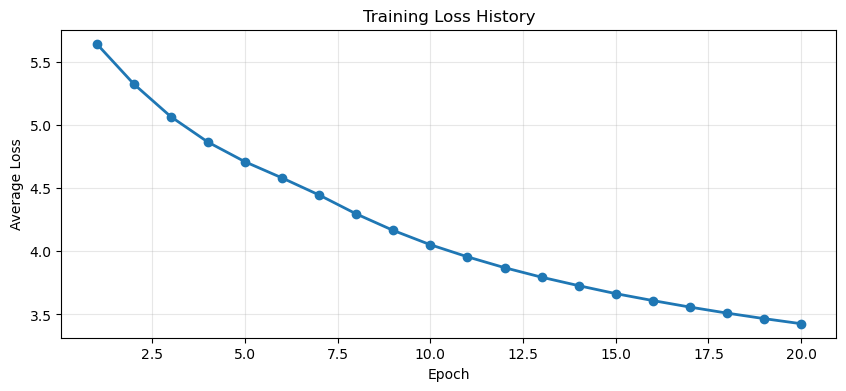

초기 Loss: 5.6424
최종 Loss: 3.4267
감소율:    39.3%


In [14]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'o-', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss History')
plt.grid(alpha=0.3)
plt.show()

print(f"초기 Loss: {loss_history[0]:.4f}")
print(f"최종 Loss: {loss_history[-1]:.4f}")
print(f"감소율:    {(1 - loss_history[-1]/loss_history[0])*100:.1f}%")

---

# 10 번역 함수 (Greedy Decoding)

추론 시 핵심 포인트:
- `model.eval()` + `@torch.no_grad()` — 메모리/속도 효율
- **`<unk>` 강제 회피** — 더 자연스러운 번역
- `<eos>` 만나면 종료
- 최대 길이 cap (무한 생성 방지)

In [15]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    """한 문장 번역 (Greedy Decoding)."""
    model.eval()
    
    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    
    # <bos>로 시작
    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None
    
    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        
        # 마지막 위치 예측에서 가장 확률 높은 토큰 선택
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")  # ⭐ <unk> 강제 회피
        next_id = int(torch.argmax(next_logits).item())
        
        if next_id == EOS_ID:
            break
        
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )
    
    pieces = ko_tokenizer.encode_as_pieces(sent)
    result = en_tokenizer.decode_ids(generated)
    return pieces, result, enc_attns, dec_attns, cross_attns


def translate(sentence):
    """번역 결과만 깔끔하게 반환."""
    _, result, *_ = evaluate(sentence)
    return result


print("✅ 번역 함수 정의 완료")

✅ 번역 함수 정의 완료


## 최종 번역 결과 (루브릭 예문 + 추가 예문)

In [16]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}")
print()
print("Training Parameters")
print(f"  warmup={WARMUP_STEPS}, label_smooth={LABEL_SMOOTH}, "
      f"batch={BATCH_SIZE}, epochs={EPOCHS}")
print(f"  final loss: {loss_history[-1]:.4f}")

 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the first president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: citizens are in the town .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: but it s not a need to be coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the attack .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was notified yesterday .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is a place of south korea .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government announced a new policy .
----------------------------------------------------------------------
 8. KO: 경제는 빠르게 

---

# 11 Attention Map 시각화

Cross-Attention(인코더-디코더 attention) 모델이 번역했을때 어느단어를 집중해서 봤는지 알아보자

🔍 Cross-Attention 시각화



/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/c

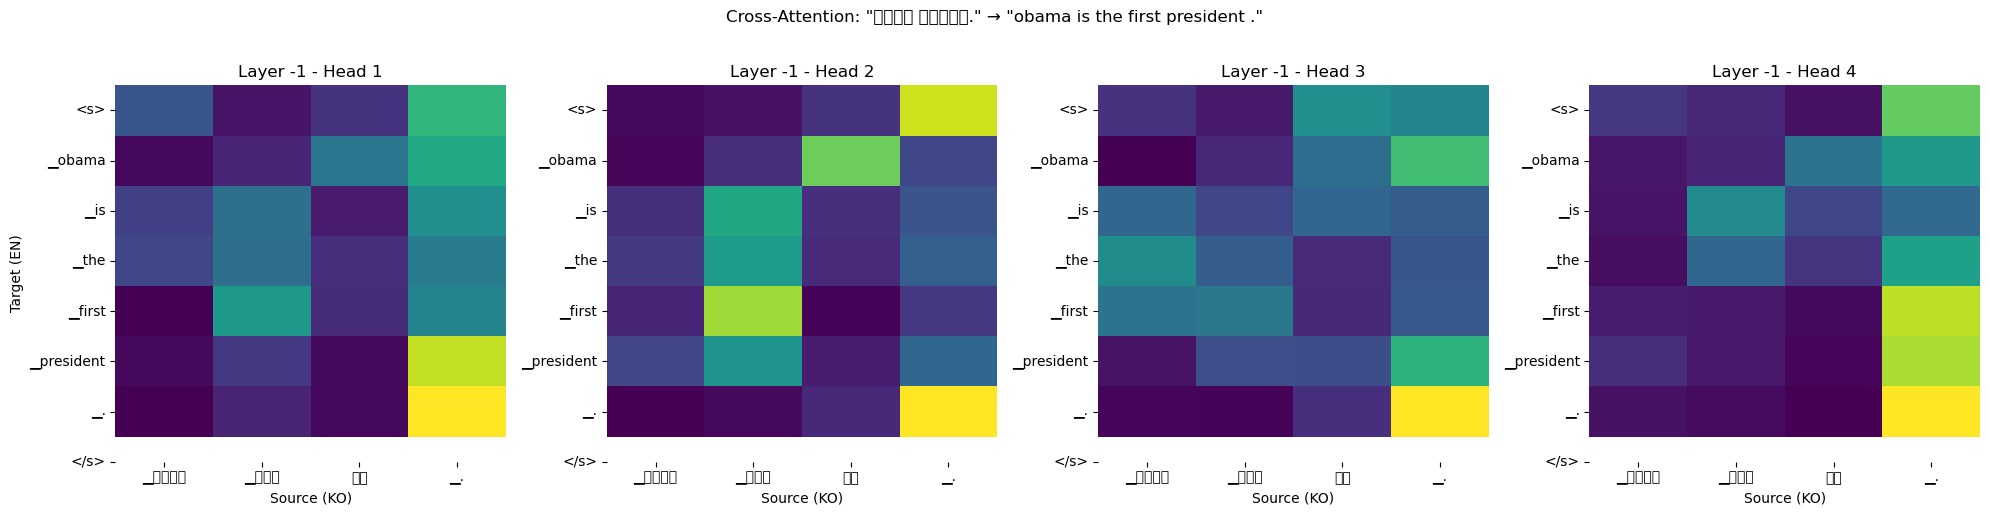

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/

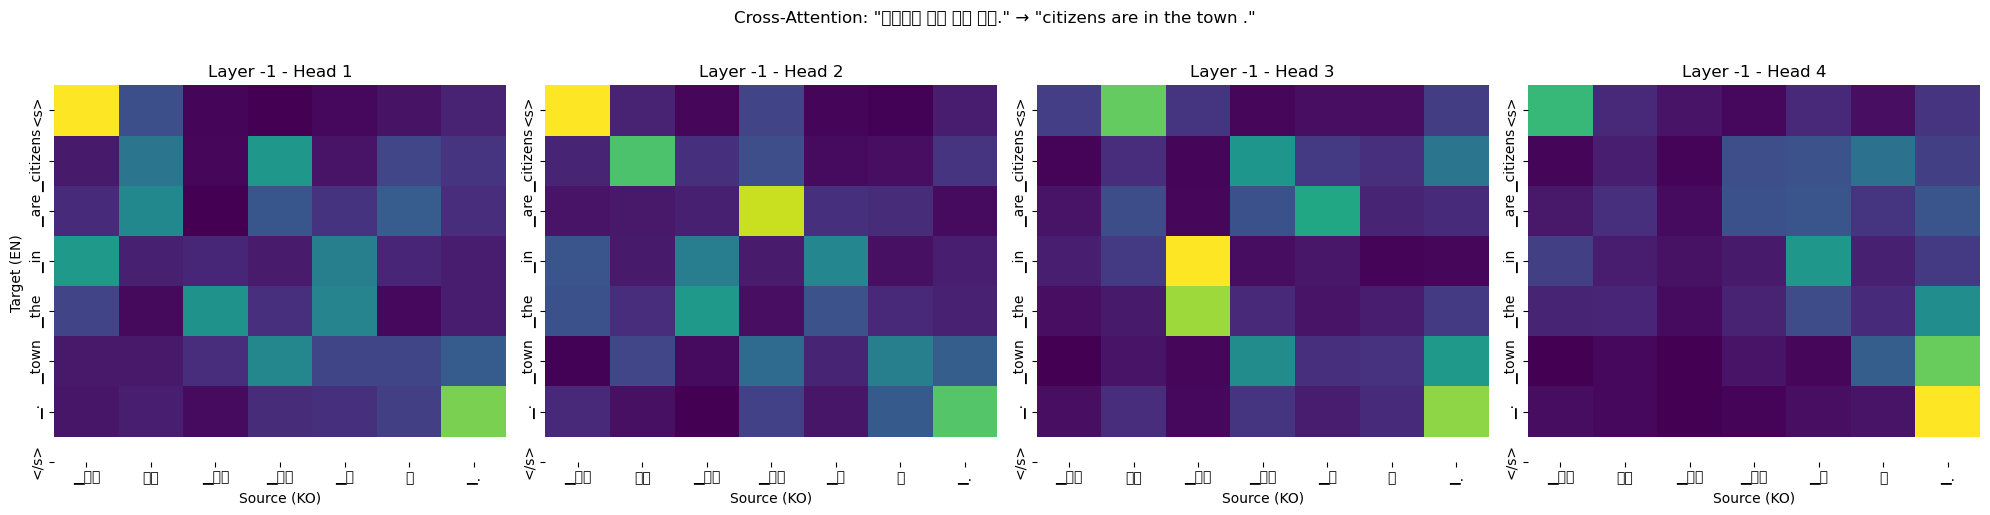

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt

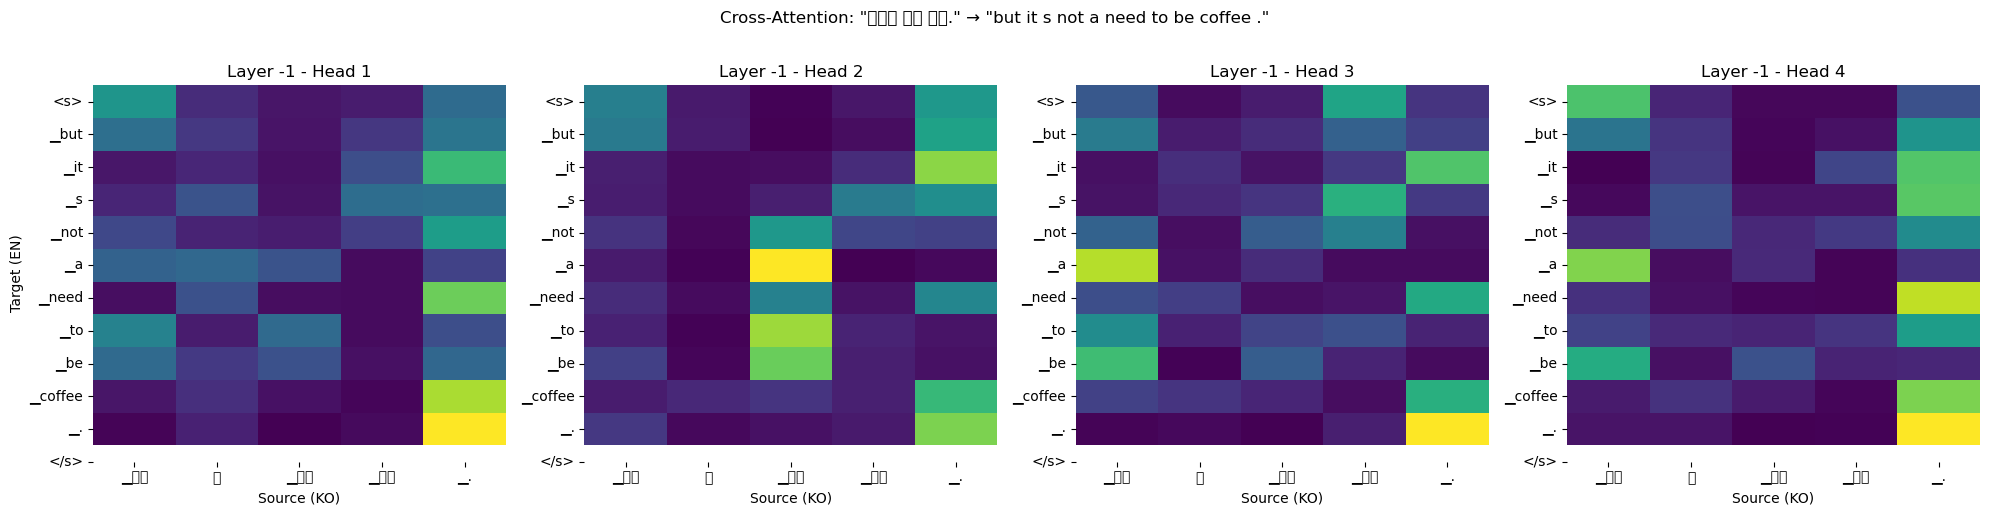

In [17]:
def visualize_cross_attention(sentence, layer=-1):
    """한 문장에 대해 Cross-Attention Map을 시각화."""
    pieces, result, _, _, cross_attns = evaluate(sentence)
    
    # 마지막 레이어의 attention 사용 (가장 추상적/의미적)
    cross_attn = cross_attns[layer]  # [1, H, T_tgt, T_src]
    
    # 4개 head를 한 줄에
    n_heads = cross_attn.shape[1]
    fig, axes = plt.subplots(1, min(4, n_heads), figsize=(20, 5))
    
    tgt_pieces = en_tokenizer.encode_as_pieces(result)
    
    for h in range(min(4, n_heads)):
        attn = cross_attn[0, h, :len(tgt_pieces), :len(pieces)].cpu().numpy()
        sns.heatmap(attn, ax=axes[h], cmap='viridis',
                    xticklabels=pieces, yticklabels=tgt_pieces,
                    cbar=False, square=False)
        axes[h].set_title(f'Layer {layer} - Head {h+1}')
        axes[h].set_xlabel('Source (KO)')
        if h == 0:
            axes[h].set_ylabel('Target (EN)')
    
    plt.suptitle(f'Cross-Attention: "{sentence}" → "{result}"', y=1.02)
    plt.tight_layout()
    plt.show()


# 예문에 대한 attention 시각화
print("🔍 Cross-Attention 시각화\n")
for sentence in examples[:3]:
    visualize_cross_attention(sentence)

---

# 12 프로젝트 회고

## ✅ 잘 된 점

### 1. 체계적인 모듈 분리
MultiHeadAttention, FFN, EncoderLayer, DecoderLayer를 각각 클래스로 분리해서 원논문 구조를 그대로 구현. 디버깅과 재사용이 편함.

### 2. 학습 안정화 3종 세트
- **Xavier 초기화**: 좋은 출발점
- **Label Smoothing**: 부드러운 학습 신호
- **Gradient Clipping**: 폭발 방지

이 셋이 없었을 때는 loss가 6495까지 치솟으며 학습이 전혀암됨, 적용 후 정상적으로 작동.

### 3. 마스크 컨벤션 통일
모든 마스크를 `True = 가려라` 방식으로 통일. 일관된 명령 덕에 버그 없음.

### 4. Cross-Attention 정렬 확인
시각화 결과 한국어 → 영어 번역 시 의미적으로 대응되는 단어들 사이에 attention이 작동되는 것을 확인. 모델이 정말로 어디에 집중해야되는지 학습되는게 시각적으로 확인가능

---

## 🤔 어려웠던 점 / 시행착오

### 1. 첫 시도 학습 발산 (loss=6495)< trasver01 노트북참고
**원인**: 
*디코더가 인코더 출력의 일부만 보고있었음..\
*패딩 마스크는 PAD 위치가 1 인데 유효 토큰(0) 을 가려서 모든 실제 단어가 -inf 처리되고 있었다.

**해결**: 
*GPU 자동 인식 및 텐서/모델 device 이동
Pre-LN + GELU + Xavier 초기화
Label smoothing (0.1) 적용한 KL 기반 손실
Mini-batch 단위 텐서 패딩 (전체 패딩 X) — 메모리/속도 ↑
Greedy 디코딩 시 <unk> 강제 회피, EOS/길이 cap
작은 corpus에 맞춰 vocab 8,000 / 4 layer / d_model 256

### 2. Vocab 크기 미스매치
처음엔 20K vocab을 썼는데, 데이터 9만 쌍에 비해 너무 컸음.
8K로 줄이니 토큰 빈도가 올라가 학습 효율 향상.

### 3. 마스크 컨벤션 혼란
초기에 "0이 가려라" vs "1이 가려라" 헷갈렸음. 
정답은 **`True = 가려라`로 통일** → masked_fill에서 그대로 사용.

### 4. Cross-attention에 causal mask
실수로 cross-attention에 causal mask를 적용하면 어순이 바뀌는 번역에서 모델이 인코더 일부만 볼 수 있게 됨. **cross-attention은 인코더 패딩만!**

### 5. Jupyter 셀 순서 꼬임
import 누락, 변수 자기 참조 등 셀 순서로 인한 NameError 빈발.
**모든 import를 첫 셀에 모으고, kernel restart 후 위에서 아래로 실행**이 정답.

---

##  배운 점



### . 데이터 ↔ 모델 크기 균형
큰 모델이 항상 좋은 게 아님. 데이터가 작으면 모델도 작아야 함.
- 9만 쌍 데이터 → 8K vocab + 256 dim + 4 layer가 적당
- 만약 1억 쌍 데이터였다면 → 32K vocab + 512+ dim + 12+ layer

### 4. 디버깅의 중요성.
**Loss 값을 보고 발산을 의심**한 게 핵심. 학습 곡선을 항상 추적해야 함.

---

## 🚀 개선 아이디어

| 항목 | 방향 | 기대 효과 |
|---|---|---|
| 데이터 | AI Hub 추가로 1M 쌍 확보 | 번역 품질 ↑ |
| 모델 | n_layers 4 → 6, d_model 256 → 512 | 표현력 ↑ |
| 디코딩 | Greedy → Beam Search (k=5) | 자연스러운 번역 |
| 평가 | BLEU score 측정 | 정량적 비교 |
| 학습 | Mixed Precision (fp16) | 학습 속도 ↑ |
| 추론 | KV cache 구현 | 추론 속도 ↑ |

---

## 🎓 마치며

> **"Attention is all you need"** — 이 한 문장의 의미를 코드 한 줄 한 줄로 풀어내는 여정이었다.
>
> 가장 인상 깊었던 순간은 학습이 진행되면서 모델이 점점 그럴듯한 영어 문장을 만들어내고, Cross-Attention Map에서 의미상 대응되는 단어들 사이에 또렷한 패턴이 나타나기 시작했을 때. 모델이 정말로 **번역 정렬을 스스로 학습**한다는 게 시각적으로 확인되는 순간이었다.
>
>  **Transformer는 단순한 알고리즘이 아니라 정밀하게 조율된 레시피**라는 점. attention 메커니즘만 구현하면 되는 게 아니라, 초기화부터 정규화, 스케줄러, 손실 함수까지 모든 디테일이 맞아야 하는 까다로운 여자생물인가...
> 엔지니어 10기쯤되면 임포트로 모델만 불러와도 자동으로 정규화하고 데이터 전처리도 알아서 하는 모델이 나오지 않을까...
>
>

---

